# Toxic Comments Classification - SVM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: Multilingual detection of hate speech against immigrants and women in Twitter (English and Spanish tweets). It is avaialble at http://hatespeech.di.unito.it/hateval.html.


The comments are divided in two classes: toxic and normal.

Algorithme used: SVC

Preprocessing techniques used:
* Convert text to lowercase
* Stemming
* Lemmatization
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import sys
sys.getrecursionlimit()

3000

In [2]:
sys.setrecursionlimit(5000)
sys.getrecursionlimit()

5000

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize,pos_tag

# 2. Data Preparation 

In [4]:
# Load training data
df = pd.read_csv('../../Data/train_set4.csv')
df.head()

,id,text,tox,tokenized
0,30351,2few recognize that refugee crisis & associate...,0,"['2few', 'recognize', 'that', 'refugee', 'cris..."
1,31565,@RandomRandomero @shoe0nhead Also shut up abou...,1,"['@', 'RandomRandomero', '@', 'shoe0nhead', 'A..."
2,764,WATCH: Democratic Senator Doesn't Understand T...,1,"['WATCH', ':', 'Democratic', 'Senator', 'Does'..."
3,2106,IS-puppets tried to roll me over three times! ...,1,"['IS-puppets', 'tried', 'to', 'roll', 'me', 'o..."
4,5979,WHO.. ARE. YOOUU? This is not mario kart. You ...,1,"['WHO', '..', 'ARE', '.', 'YOOUU', '?', 'This'..."


In [5]:
# Load testing data
test = pd.read_csv('../../Data/test_set4.csv')
test.head()

,id,text,tox,tokenized
0,3816,#BuildThatWall #Meritbased get the ILLEGAL sit...,1,"['#', 'BuildThatWall', '#', 'Meritbased', 'get..."
1,2737,Angels Don't Die. I think it's better that two...,0,"['Angels', 'Do', ""n't"", 'Die', '.', 'I', 'thin..."
2,5598,When your girls actin a fool so you let your s...,1,"['When', 'your', 'girls', 'actin', 'a', 'fool'..."
3,19183,@PYS_FlyATL You pussy.,0,"['@', 'PYS_FlyATL', 'You', 'pussy', '.']"
4,1699,Tomorrow night our guest speaker is Madeleine ...,0,"['Tomorrow', 'night', 'our', 'guest', 'speaker..."


# 3. Preprocessing

In [6]:
stemmer = PorterStemmer()

def stemming_token (comment):     
    for word in comment.split():
        comment = comment.replace(word, stemmer.stem(word)) # Converting words to their root forms
    return comment

In [7]:
wordnet = WordNetLemmatizer() # Initialize wordnet lemmatizer

def lemmatize_token (text):
    s = []

    for token,tag in pos_tag(word_tokenize(text)): # tokenize text
        pos=tag[0].lower()
        
        # check token's POS tag
        if pos not in ['a', 'r', 'v', 's']:
            pos='n'
    
        s.append(wordnet.lemmatize(token,pos)) # Lemmatize list of words with pos tag
    
    sentence = (" ").join(s) # join lemmatized word
    return sentence

In [8]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    stem_comment = stemming_token (comment) # stemming comment
    lem_comment = lemmatize_token (stem_comment) # lemmatize comment  
    
    return lem_comment

In [9]:
# clean and normalize comments
df['text'] = df['text'].map(lambda word:clean_text(word))
test['text'] = test['text'].map(lambda word:clean_text(word))

In [10]:
x_train = df['text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(10400,)
(10400,)


In [11]:
X_test = test['text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(2600,)
(2600,)


# 3. Classifier training (SVC)

### Create pipeline

In [12]:
# create a pipeline
SVC_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', SVC(kernel='rbf', C=1, gamma='scale'))
            ])

### Train classifier

In [13]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (SVC_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

In [14]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set4_approach#23_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [15]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.7478
recall :  0.6480
F1_score :  0.6817
precision :  0.7191


# 4. Predictions

### Test set

In [16]:
# predict test data
preds_test = cross_val_predict(SVC_pipeline, X_test, Y_test, cv=5)

In [17]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[1135  330]
 [ 413  722]]


In [18]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.73      0.77      0.75      1465
       toxic       0.69      0.64      0.66      1135

    accuracy                           0.71      2600
   macro avg       0.71      0.71      0.71      2600
weighted avg       0.71      0.71      0.71      2600



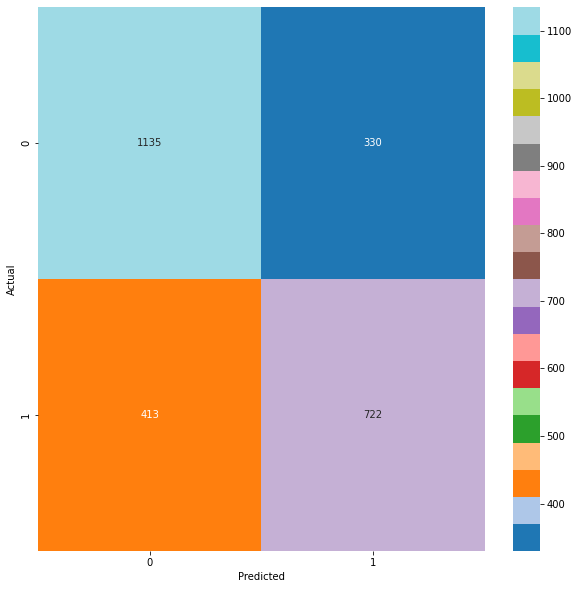

In [19]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7142
recall :  0.6361
F1_score :  0.6603
precision :  0.6863


# 5. Save results to Excel file

In [21]:
# define tarjet
newFile = "../results_set4.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #23', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 25

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)